In [406]:
import os
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


# Folder containing your 190+ CSVs
folder_path = '/Users/will/Documents/Beacon MVP/Projects/IESO Data Set Up/output_data/weather_hourly_combined'
temp_folder = '/Users/will/Documents/Beacon MVP/Projects/IESO Data Set Up/temp_files/'

# Combine all weather csvs

In [349]:

all_dfs = []
log = []

def detect_metadata_and_column_count(filepath):
    """Detect number of metadata lines by scanning until the first valid header is found."""
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = []
        for _ in range(25):  # Read up to 25 lines to search for header
            try:
                lines.append(next(f))
            except StopIteration:
                break  # End of file before 25 lines

    for i in range(len(lines) - 1):
        col_count_curr = len(lines[i].strip().split(","))
        col_count_next = len(lines[i+1].strip().split(","))

        if col_count_curr == col_count_next and col_count_curr > 1:
            # Likely header found
            if i > 0:
                print(f'"{os.path.basename(filepath)}" has metadata: skipping {i} rows')
            return i, col_count_curr

    # Fallback if no match found
    print(f'"{os.path.basename(filepath)}" has an unknown structure (no matching header found)')
    return 0, len(lines[0].strip().split(","))

# Loop through all CSVs
for file in os.listdir(folder_path):
    if not file.endswith(".csv"):
        continue

    filepath = os.path.join(folder_path, file)

    try:
        # Step 1: Detect header row & column count
        skiprows, expected_cols = detect_metadata_and_column_count(filepath)

        # Step 2: Read the file safely
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            df = pd.read_csv(f, skiprows=skiprows, on_bad_lines="skip")

        # Step 3: Optional sanity check
        if df.shape[1] != expected_cols:
            log.append((file, f"Column mismatch: expected {expected_cols}, got {df.shape[1]}"))
            continue

        all_dfs.append(df)

    except Exception as e:
        log.append((file, str(e)))

# Save final dataframe if needed
if all_dfs:
    df_all = pd.concat(all_dfs, ignore_index=True)
    print(f"✅ Combined data shape: {df_all.shape}")
else:
    print("❌ No valid dataframes loaded.")


✅ Combined data shape: (2649144, 31)


In [350]:
df_all['Climate ID'].nunique()

151

# Remove weather stations that report no Temp data

In [355]:
#df_all['Climate ID'] = df['Climate ID'].astype(str)


In [356]:
# Step 1: Identify Climate IDs with all NaN in 'Temp'
ClimateID_all_nan = df_all.groupby('Climate ID')['Temp (°C)'].apply(lambda x: x.isna().all())

# Step 2: Extract only those Climate IDs
ClimateID_to_remove = ClimateID_all_nan[ClimateID_all_nan].index.tolist()

# Step 3: Remove rows where 'Climate ID' is in the list
df_remaining = df_all[~df_all['Climate ID'].isin(ClimateID_to_remove)].copy()

# Step 4: Print removed Climate IDs
no_ClimateID_removed = len(ClimateID_to_remove)
total_no_ClimateID = df_all['Climate ID'].nunique()
no_ClimateID_left = total_no_ClimateID - len(ClimateID_to_remove)
print(f'no. ClimateID removed: {no_ClimateID_removed}')
print(f'no. ClimateID left: {no_ClimateID_left}')
print("🚫 Removed ClimateID (no Temp values at all):")
for ID in ClimateID_to_remove:
    print("-", ID)

no. ClimateID removed: 90
no. ClimateID left: 61
🚫 Removed ClimateID (no Temp values at all):
- 6010738
- 6032120
- 6048261
- 6052259
- 6055378
- 6061361
- 6074211
- 6078285
- 6085703
- 6100176
- 6101875
- 6104125
- 6106000
- 6106022
- 6106100
- 6106103
- 6106396
- 6109517
- 6110552
- 6110617
- 6110967
- 6115524
- 6116200
- 6116201
- 6119494
- 6122849
- 6127514
- 6130681
- 6136290
- 6136303
- 6136305
- 6136308
- 6137287
- 6137730
- 6139525
- 6143089
- 6145503
- 6149387
- 6153170
- 6153194
- 6155200
- 6156130
- 6156131
- 6156133
- 6156134
- 6156135
- 6156136
- 6156137
- 6156138
- 6156150
- 6156152
- 6156153
- 6156154
- 6156156
- 6156157
- 6156159
- 6156160
- 6156161
- 6156164
- 6156165
- 6156166
- 6156168
- 6156169
- 6156170
- 6156171
- 6156172
- 6156174
- 6156175
- 6156177
- 6156179
- 6156180
- 6156181
- 6156182
- 6156183
- 6156184
- 6156186
- 6156187
- 6158350
- 6158440
- 6158442
- 6158749
- 6158872
- 6166400
- 6166418
- 604I261
- 605DJ25
- 607EP80
- 6119K9K
- 611B001
- 611BKE0


In [274]:
df_remaining.columns

Index(['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID',
       'Date/Time (LST)', 'Year', 'Month', 'Day', 'Time (LST)', 'Flag',
       'Temp (°C)', 'Temp Flag', 'Dew Point Temp (°C)', 'Dew Point Temp Flag',
       'Rel Hum (%)', 'Rel Hum Flag', 'Precip. Amount (mm)',
       'Precip. Amount Flag', 'Wind Dir (10s deg)', 'Wind Dir Flag',
       'Wind Spd (km/h)', 'Wind Spd Flag', 'Visibility (km)',
       'Visibility Flag', 'Stn Press (kPa)', 'Stn Press Flag', 'Hmdx',
       'Hmdx Flag', 'Wind Chill', 'Wind Chill Flag', 'Weather'],
      dtype='object')

In [357]:
# explore stations that have a lot of missing values

nan_summary = df_remaining.groupby('Climate ID').agg(
    Climate_ID=('Climate ID', 'first'),  # or 'max', 'min' if consistent
    total_count=('Temp (°C)', 'count'),
    missing_count=('Temp (°C)', lambda x: x.isna().sum())
)
nan_summary['missing_pct'] = 100 * nan_summary['missing_count'] / (nan_summary['missing_count'] + nan_summary['total_count'])
nan_summary = nan_summary.sort_values('missing_pct', ascending=False)
print(nan_summary)

nan_summary[nan_summary['missing_pct']>5]

           Climate_ID  total_count  missing_count  missing_pct
Climate ID                                                    
604S001       604S001          286          17258    98.369813
6111792       6111792         4105          13439    76.601687
613F606       613F606         4570          12974    73.951208
6166456       6166456         6270          11274    64.261286
6158409       6158409         6642          10902    62.140903
...               ...          ...            ...          ...
6048260       6048260        17532             12     0.068399
6166415       6166415        17532             12     0.068399
6119498       6119498        17537              7     0.039900
6057591       6057591        17540              4     0.022800
6158731       6158731        17542              2     0.011400

[61 rows x 4 columns]


,Climate_ID,total_count,missing_count,missing_pct
Climate ID,,,,
604S001,604S001,286,17258,98.369813
6111792,6111792,4105,13439,76.601687
613F606,613F606,4570,12974,73.951208
6166456,6166456,6270,11274,64.261286
6158409,6158409,6642,10902,62.140903
6037201,6037201,10907,6637,37.830597
6137286,6137286,10965,6579,37.500000
6119M51,6119M51,11520,6024,34.336525
6104149,6104149,13157,4387,25.005700


In [358]:
nan_summary[nan_summary['missing_pct']>5]

,Climate_ID,total_count,missing_count,missing_pct
Climate ID,,,,
604S001,604S001,286,17258,98.369813
6111792,6111792,4105,13439,76.601687
613F606,613F606,4570,12974,73.951208
6166456,6166456,6270,11274,64.261286
6158409,6158409,6642,10902,62.140903
6037201,6037201,10907,6637,37.830597
6137286,6137286,10965,6579,37.500000
6119M51,6119M51,11520,6024,34.336525
6104149,6104149,13157,4387,25.005700


In [359]:
bad_stations = nan_summary[nan_summary['missing_pct']>5].index

In [360]:
list(bad_stations)
# Climate IDs with letters are strings
# Climate IDs without are float or int(?)

['604S001',
 6111792,
 '613F606',
 6166456,
 6158409,
 6037201,
 6137286,
 '6119M51',
 6104149,
 6049470,
 6157000,
 6151684]

In [361]:
len(bad_stations)

12

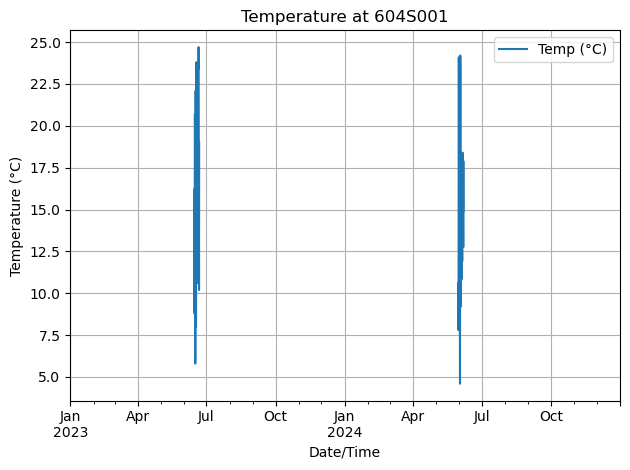

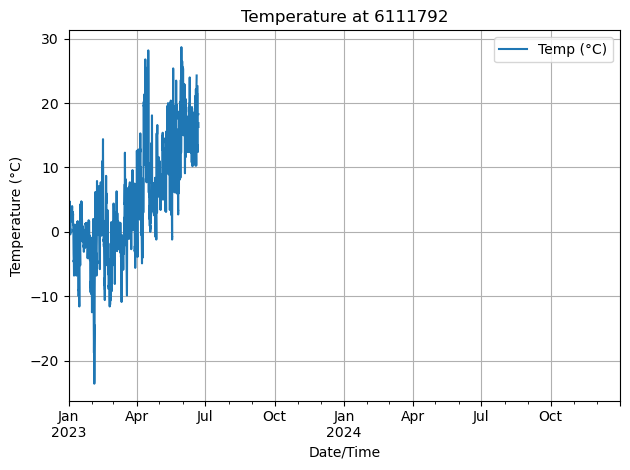

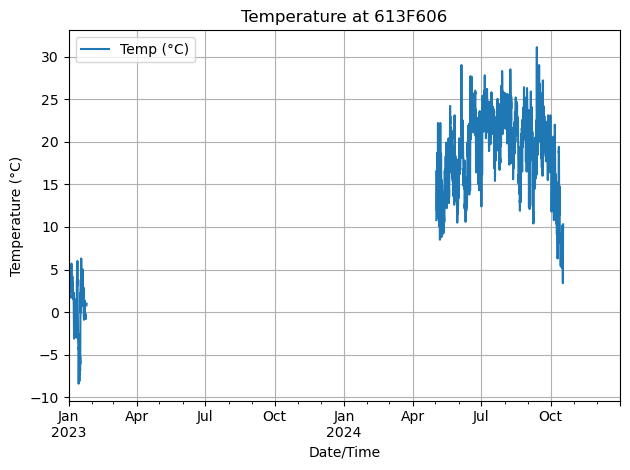

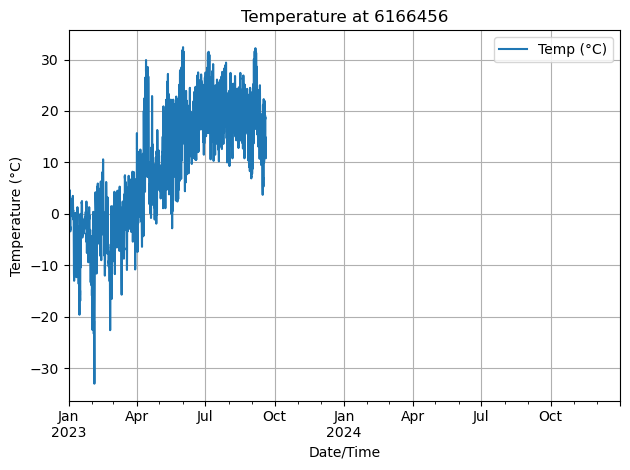

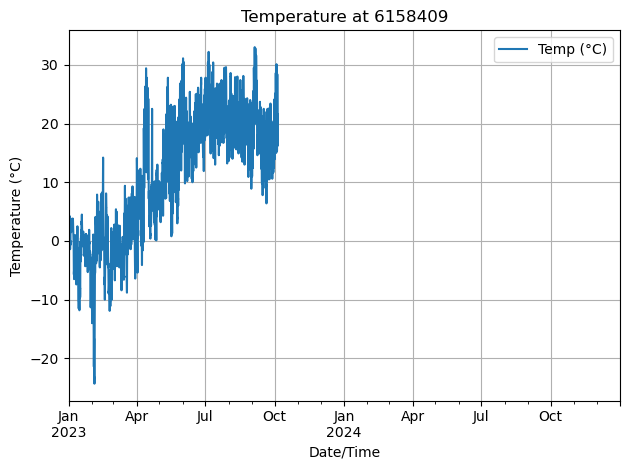

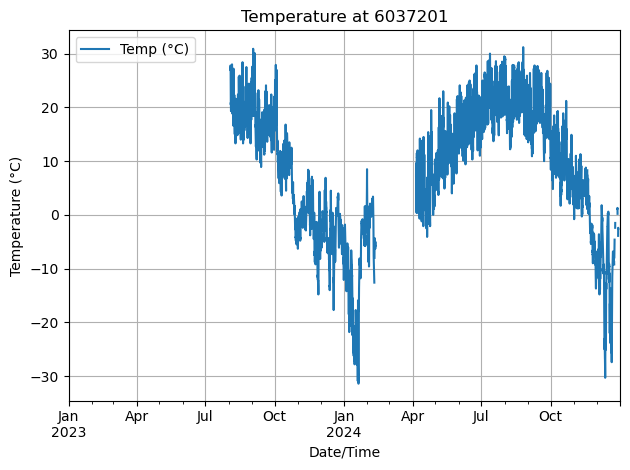

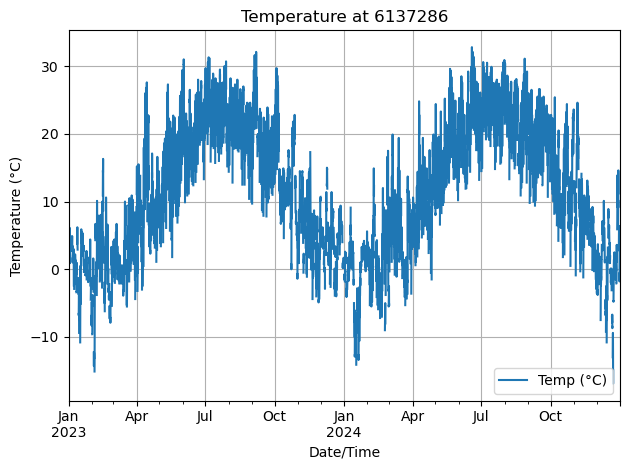

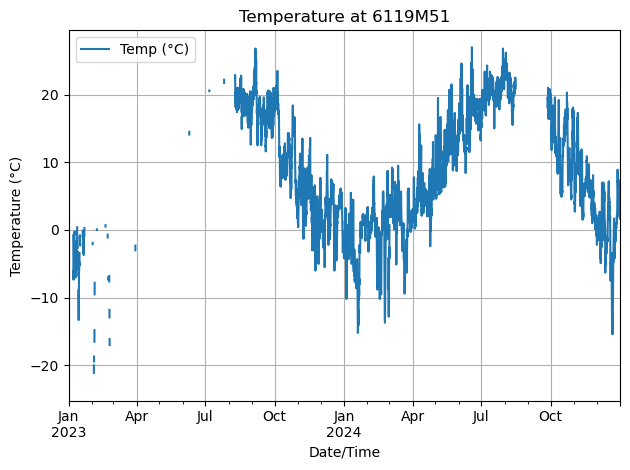

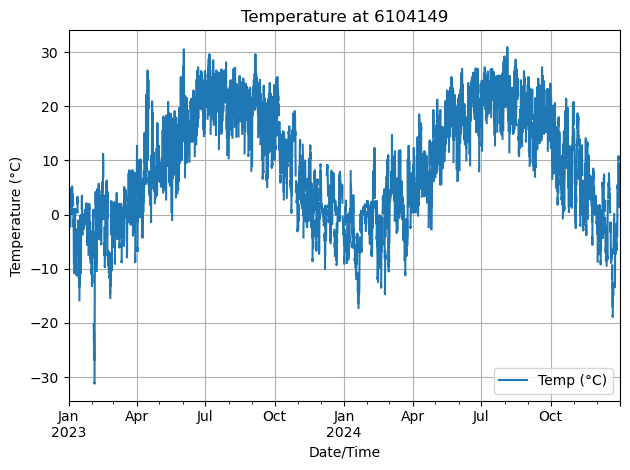

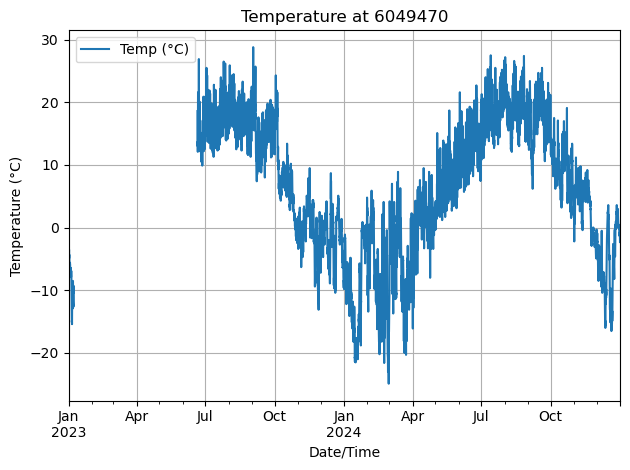

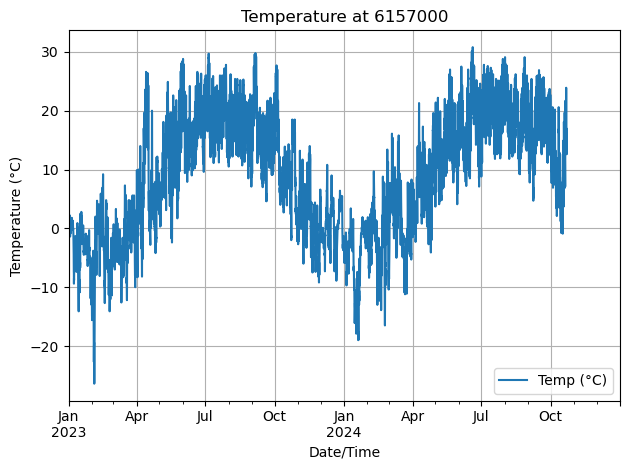

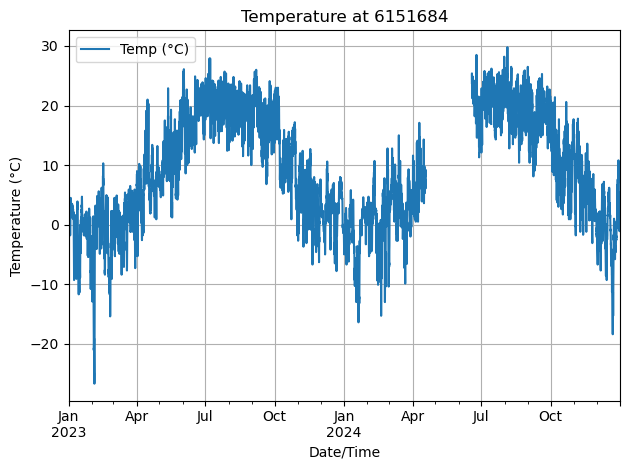

In [362]:
for station in bad_stations:
    df_plot = df_all[df_all["Climate ID"] == station][['Date/Time (LST)', 'Temp (°C)']].copy()

    # Convert datetime column
    df_plot['Date/Time (LST)'] = pd.to_datetime(df_plot['Date/Time (LST)'], errors='coerce')

    # Plot
    ax = df_plot.plot(x='Date/Time (LST)', y='Temp (°C)', kind='line', title=f"Temperature at {station}")
    ax.set_ylabel("Temperature (°C)")
    ax.set_xlabel("Date/Time")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [363]:
# based on above plots we can keep
good_enough_stations = [6137286,6104149]

bad_stations2 = [item for item in list(bad_stations) if item not in good_enough_stations]

In [364]:
len(bad_stations2)

10

In [365]:
df_remaining['Climate ID'].nunique()
# 61 stations before removing station with a lot of missing data

61

In [366]:
df_remaining = df_remaining[~df_remaining['Climate ID'].isin(bad_stations2)]

In [367]:
df_remaining['Climate ID'].nunique()
# 51 stations after removing stations with bad data 

51

# Generate .csv of remaining weather stations to plot in QGIS

In [393]:
mapping_folder = '/Users/will/Documents/Beacon MVP/Projects/IESO Data Set Up/Weather stations to FSAs/'

old_stations = pd.read_csv(os.path.join(mapping_folder + 'Hourly Station Inventory no header.csv'))

# need to format IDs to same type and remove white spaces
df_remaining['Climate ID'] = df_remaining['Climate ID'].astype(str).str.strip()
old_stations['Climate ID'] = old_stations['Climate ID'].astype(str).str.strip()
remaining_station_list = list(df_remaining['Climate ID'].unique())

remaining_stations = old_stations[old_stations['Climate ID'].isin(remaining_station_list)].copy()

remaining_stations.to_csv(os.path.join(mapping_folder +'Remaining_weather_stations.csv'))

# Export unclean master weather data 

In [394]:
# Filter to just relevant columns
df_export = df_remaining[['Date/Time (LST)','Climate ID','Temp (°C)']]

In [395]:
len(df_export)

894744

In [396]:
df_export.head()

,Date/Time (LST),Climate ID,Temp (°C)
0,2023-01-01 00:00,6117700,1.1
1,2023-01-01 01:00,6117700,0.7
2,2023-01-01 02:00,6117700,0.8
3,2023-01-01 03:00,6117700,0.3
4,2023-01-01 04:00,6117700,0.2


In [407]:
df_export.to_csv(os.path.join(temp_folder, 'grouped_weather_data_unclean.csv'),index=False)

# Exploratory analysis

In [398]:
# Automated exploratory analysis
from ydata_profiling import ProfileReport
import pandas as pd

profile = ProfileReport(df_export, title="Training Data Profile", explorative=True)
profile.to_file("temp_data_training_data_report.html")  # or .to_notebook_iframe()


/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)
Summarize dataset:   0%|    | 0/8 [00:00<?, ?it/s, Describe variable: Temp (°C)]
Summarize dataset:  12%|▏| 1/8 [00:03<00:24,  3.52s/it, Describe variable: Temp 
Export report to file: 100%|█████████████████████| 1/1 [00:00<00:00, 213.71it/s]


# Examine missing data

In [121]:
#How many NaN values

nan_count = df_export['Temp (°C)'].isna().sum()
nan_percent = (nan_count/(len(df_export)))*100
print(f"NaN count in 'Temp (°C)': {nan_count}")
print(f"NaN percent: {nan_percent.round(2)}%")

NaN count in 'Temp (°C)': 135359
NaN percent: 12.25%


In [123]:
nan_rows = df_export[df_export['Temp (°C)'].isna()]


In [124]:
nan_rows.head()

,Date/Time (LST),Climate ID,Temp (°C)
6321,2023-09-21 09:00,6117700,NaN
6322,2023-09-21 10:00,6117700,NaN
6323,2023-09-21 11:00,6117700,NaN
6324,2023-09-21 12:00,6117700,NaN
6325,2023-09-21 13:00,6117700,NaN


In [126]:
# How many days are missing a every hour?
nan_rows['Date/Time (LST)'] = pd.to_datetime(nan_rows['Date/Time (LST)'])
nan_rows['date'] = nan_rows['Date/Time (LST)'].dt.date

daily_counts = nan_rows.groupby(['date','Climate ID']).size().reset_index(name='row_count')

print(daily_counts)
# how much missing data is there... 
# there are many weather stations that have at least a complete day of missing data, potentially consecutive dates missing
print('how many entries do we have of substations missing entire days worth of data, also data for other hours')
daily_counts['row_count'].value_counts()

            date Climate ID  row_count
0     2023-01-01    6037201         24
1     2023-01-01    6092919         24
2     2023-01-01    6104149          6
3     2023-01-01    6137286          9
4     2023-01-01    6153194         24
...          ...        ...        ...
7205  2024-12-31    6158409         24
7206  2024-12-31    6166418         24
7207  2024-12-31    6166456         24
7208  2024-12-31    604S001         24
7209  2024-12-31    613F606         24

[7210 rows x 3 columns]
how many entries do we have of substations missing entire days worth of data, also data for other hours


/var/folders/06/r1b4q53n1z9c4xqz_6bqq9zc0000gn/T/ipykernel_31423/574140408.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nan_rows['Date/Time (LST)'] = pd.to_datetime(nan_rows['Date/Time (LST)'])
/var/folders/06/r1b4q53n1z9c4xqz_6bqq9zc0000gn/T/ipykernel_31423/574140408.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nan_rows['date'] = nan_rows['Date/Time (LST)'].dt.date


row_count
24    5013
6      749
9      736
1      345
2       52
3       46
4       41
23      35
5       29
7       26
13      17
12      14
8       14
22      14
14      14
10      10
15      10
16       9
21       8
20       7
18       6
11       6
19       6
17       3
Name: count, dtype: int64

In [399]:
df_export.head()

,Date/Time (LST),Climate ID,Temp (°C)
0,2023-01-01 00:00,6117700,1.1
1,2023-01-01 01:00,6117700,0.7
2,2023-01-01 02:00,6117700,0.8
3,2023-01-01 03:00,6117700,0.3
4,2023-01-01 04:00,6117700,0.2


In [402]:
df_export[df_export['Climate ID']=='6022474']

,Date/Time (LST),Climate ID,Temp (°C)
1508784,2023-01-01 00:00,6022474,-4.9
1508785,2023-01-01 01:00,6022474,-4.9
1508786,2023-01-01 02:00,6022474,-4.9
1508787,2023-01-01 03:00,6022474,-5.0
1508788,2023-01-01 04:00,6022474,-5.1
...,...,...,...
1526323,2024-12-31 19:00,6022474,-7.1
1526324,2024-12-31 20:00,6022474,-7.2
1526325,2024-12-31 21:00,6022474,-7.7
1526326,2024-12-31 22:00,6022474,-8.1
